## Loading Data and preprocessing

In [12]:
import gzip
import json

def load_json_gz(path, max_samples=1000):  # small sample first
    data = []
    
    with gzip.open(path, 'rt', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if i >= max_samples:
                break
                
            review = json.loads(line)
            
            if 'reviewText' in review and 'overall' in review:
                data.append({
                    'text': review['reviewText'],
                    'rating': review['overall']
                })
    
    return data

sample_data = load_json_gz('Dataset/electronics.json.gz')
print(len(sample_data))
print(sample_data[0])

1000
{'text': 'We got this GPS for my husband who is an (OTR) over the road trucker.  Very Impressed with the shipping time, it arrived a few days earlier than expected...  within a week of use however it started freezing up... could of just been a glitch in that unit.  Worked great when it worked!  Will work great for the normal person as well but does have the "trucker" option. (the big truck routes - tells you when a scale is coming up ect...)  Love the bigger screen, the ease of use, the ease of putting addresses into memory.  Nothing really bad to say about the unit with the exception of it freezing which is probably one in a million and that\'s just my luck.  I contacted the seller and within minutes of my email I received a email back with instructions for an exchange! VERY impressed all the way around!', 'rating': 5.0}


In [13]:
electronics = load_json_gz('Dataset/electronics.json.gz', 12000)
home = load_json_gz('Dataset/home.json.gz', 12000)
sports = load_json_gz('Dataset/sports.json.gz', 12000)

dataset = electronics + home + sports

print("Total:", len(dataset))

Total: 36000


In [14]:
import pandas as pd

df = pd.DataFrame(dataset)
df = df.dropna()

print(df.head())

                                                text  rating
0  We got this GPS for my husband who is an (OTR)...     5.0
1  I'm a professional OTR truck driver, and I bou...     1.0
2  Well, what can I say.  I've had this unit in m...     3.0
3  Not going to write a long review, even thought...     2.0
4  I've had mine for a year and here's what we go...     1.0


In [15]:
def map_sentiment(rating):
    if rating <= 2:
        return 0
    elif rating == 3:
        return 1
    else:
        return 2

df['sentiment'] = df['rating'].apply(map_sentiment)

In [16]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print(len(train_df), len(val_df), len(test_df))

25200 5400 5400


In [17]:
import re

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    # Keeps alphanumeric characters
    text = re.sub(r'[^a-z0-9\s]', '', text) 
    return text

In [18]:
train_df['clean_text'] = train_df['text'].apply(clean_text)
val_df['clean_text'] = val_df['text'].apply(clean_text)
test_df['clean_text'] = test_df['text'].apply(clean_text)

In [19]:
print(clean_text(train_df['text'].iloc[0]))

awesome addition to my rebel t3i takes incredible pictures from pretty far away i am still getting used to the camera and all the settings but even on auto mode the lens works very well i am by no means a photographer but for my needs it is amazing the lens easily attaches to the camera and comes with two caps for both sides of the lens to keep the dust out and protected when not in use


In [20]:
def tokenize(text):
    return text.split()

print(tokenize(clean_text(train_df['text'].iloc[0])))

['awesome', 'addition', 'to', 'my', 'rebel', 't3i', 'takes', 'incredible', 'pictures', 'from', 'pretty', 'far', 'away', 'i', 'am', 'still', 'getting', 'used', 'to', 'the', 'camera', 'and', 'all', 'the', 'settings', 'but', 'even', 'on', 'auto', 'mode', 'the', 'lens', 'works', 'very', 'well', 'i', 'am', 'by', 'no', 'means', 'a', 'photographer', 'but', 'for', 'my', 'needs', 'it', 'is', 'amazing', 'the', 'lens', 'easily', 'attaches', 'to', 'the', 'camera', 'and', 'comes', 'with', 'two', 'caps', 'for', 'both', 'sides', 'of', 'the', 'lens', 'to', 'keep', 'the', 'dust', 'out', 'and', 'protected', 'when', 'not', 'in', 'use']


In [21]:
from collections import Counter

def build_vocab(texts, min_freq=2):
    counter = Counter()
    
    for text in texts:
        tokens = tokenize(clean_text(text))
        counter.update(tokens)
    
    vocab = {'<PAD>': 0, '<UNK>': 1}
    
    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = len(vocab)
    
    return vocab

vocab = build_vocab(train_df['text'])
print("Vocab size:", len(vocab))

Vocab size: 24630


In [22]:
def encode(text, vocab, max_len=100):
    tokens = tokenize(clean_text(text))
    
    encoded = [vocab.get(token, vocab['<UNK>']) for token in tokens]
    
    if len(encoded) < max_len:
        encoded += [vocab['<PAD>']] * (max_len - len(encoded))
    else:
        encoded = encoded[:max_len]
    
    return encoded

In [23]:
MAX_LEN = 100

train_df['encoded'] = train_df['text'].apply(lambda x: encode(x, vocab, MAX_LEN))
val_df['encoded'] = val_df['text'].apply(lambda x: encode(x, vocab, MAX_LEN))
test_df['encoded'] = test_df['text'].apply(lambda x: encode(x, vocab, MAX_LEN))

In [24]:
def length_feature(text):
    length = len(text.split())
    
    if length <= 50:
        return 0
    elif length <= 150:
        return 1
    else:
        return 2

train_df['length_label'] = train_df['text'].apply(length_feature)
val_df['length_label'] = val_df['text'].apply(length_feature)
test_df['length_label'] = test_df['text'].apply(length_feature)

## Part A

PyTorch Dataset

In [25]:
import torch
from torch.utils.data import Dataset

class ReviewDataset(Dataset):
    def __init__(self, df):
        self.X = df['encoded'].tolist()
        self.y_sent = df['sentiment'].tolist()
        self.y_len = df['length_label'].tolist()
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return (
            torch.tensor(self.X[idx], dtype=torch.long),
            torch.tensor(self.y_sent[idx], dtype=torch.long),
            torch.tensor(self.y_len[idx], dtype=torch.long)
        )

Positional Encoding

In [26]:
import math
import torch.nn as nn

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100):
        super().__init__()
        
        pe = torch.zeros(max_len, d_model)
        
        for pos in range(max_len):
            for i in range(0, d_model, 2):
                pe[pos, i] = math.sin(pos / (10000 ** ((2*i)/d_model)))
                if i+1 < d_model:
                    pe[pos, i+1] = math.cos(pos / (10000 ** ((2*i)/d_model)))
        
        self.pe = pe.unsqueeze(0)  # (1, max_len, d_model)
    
    def forward(self, x):
        return x + self.pe[:, :x.size(1)].to(x.device)

SELF-ATTENTION

In [27]:
class SelfAttention(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        
        self.Wq = nn.Linear(d_model, d_model)
        self.Wk = nn.Linear(d_model, d_model)
        self.Wv = nn.Linear(d_model, d_model)
    
    def forward(self, x):
        Q = self.Wq(x)
        K = self.Wk(x)
        V = self.Wv(x)
        
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(Q.size(-1))
        attention = torch.softmax(scores, dim=-1)
        
        out = torch.matmul(attention, V)
        return out

MULTI-HEAD ATTENTION

In [28]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        
        self.heads = nn.ModuleList(
            [SelfAttention(d_model) for _ in range(num_heads)]
        )
        
        self.fc = nn.Linear(d_model * num_heads, d_model)
    
    def forward(self, x):
        head_outputs = [head(x) for head in self.heads]
        concat = torch.cat(head_outputs, dim=-1)
        return self.fc(concat)

FEED FORWARD

In [29]:
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model)
        )
    
    def forward(self, x):
        return self.net(x)

ENCODER BLOCK

In [30]:
class EncoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff):
        super().__init__()
        
        self.attn = MultiHeadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model)
        
        self.ff = FeedForward(d_model, d_ff)
        self.norm2 = nn.LayerNorm(d_model)
    
    def forward(self, x):
        attn_out = self.attn(x)
        x = self.norm1(x + attn_out)
        
        ff_out = self.ff(x)
        x = self.norm2(x + ff_out)
        
        return x

NCODER MODEL

In [31]:
class TransformerEncoder(nn.Module):
    def __init__(self, vocab_size, d_model=128, num_heads=4, d_ff=256, num_layers=2):
        super().__init__()
        
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model)
        
        self.layers = nn.ModuleList([
            EncoderBlock(d_model, num_heads, d_ff)
            for _ in range(num_layers)
        ])
        
        # Shared representation → 3 outputs
        self.sentiment_head = nn.Linear(d_model, 3)
        self.length_head = nn.Linear(d_model, 3)
    
    def forward(self, x):
        x = self.embedding(x)
        x = self.pos_encoding(x)
        
        for layer in self.layers:
            x = layer(x)
        
        # Pooling (mean)
        representation = x.mean(dim=1)
        
        sentiment = self.sentiment_head(representation)
        length = self.length_head(representation)
        
        return sentiment, length, representation

TRAINING SETUP

In [32]:
from torch.utils.data import DataLoader

train_loader = DataLoader(ReviewDataset(train_df), batch_size=32, shuffle=True)
val_loader = DataLoader(ReviewDataset(val_df), batch_size=32)

TRAINING LOOP (COMBINED LOSS)

In [33]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TransformerEncoder(vocab_size=len(vocab)).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

Training

In [34]:
train_losses = []

for epoch in range(5):
    model.train()
    total_loss = 0
    
    for X, y_sent, y_len in train_loader:
        X, y_sent, y_len = X.to(device), y_sent.to(device), y_len.to(device)
        
        optimizer.zero_grad()
        
        pred_sent, pred_len, _ = model(X)
        
        loss1 = criterion(pred_sent, y_sent)
        loss2 = criterion(pred_len, y_len)
        
        loss = loss1 + loss2   # combined loss
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

Epoch 1, Loss: 0.7604
Epoch 2, Loss: 0.7403
Epoch 3, Loss: 0.7637
Epoch 4, Loss: 1.3959
Epoch 5, Loss: 0.7877


Evaluation

In [35]:
from sklearn.metrics import accuracy_score

model.eval()

y_true_sent, y_pred_sent = [], []
y_true_len, y_pred_len = [], []

with torch.no_grad():
    for X, y_sent, y_len in val_loader:
        X = X.to(device)
        
        pred_sent, pred_len, _ = model(X)
        
        y_pred_sent.extend(torch.argmax(pred_sent, dim=1).cpu().numpy())
        y_true_sent.extend(y_sent.numpy())
        
        y_pred_len.extend(torch.argmax(pred_len, dim=1).cpu().numpy())
        y_true_len.extend(y_len.numpy())

print("Sentiment Accuracy:", accuracy_score(y_true_sent, y_pred_sent))
print("Length Accuracy:", accuracy_score(y_true_len, y_pred_len))

Sentiment Accuracy: 0.8557407407407407
Length Accuracy: 0.872037037037037


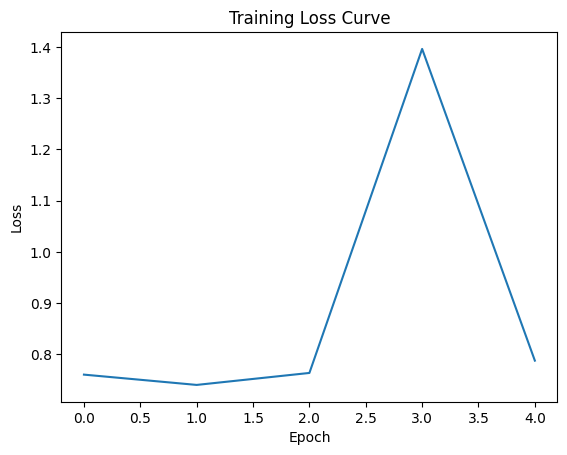

In [38]:
import matplotlib.pyplot as plt

plt.plot(train_losses)
plt.title('Training Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

Saving Embeddings

In [37]:
import numpy as np

model.eval()
embeddings = []

with torch.no_grad():
    for X, _, _ in train_loader:
        X = X.to(device)
        _, _, rep = model(X)
        embeddings.append(rep.cpu().numpy())

embeddings = np.vstack(embeddings)

np.save("results/train_embeddings.npy", embeddings)

## Part B

LOAD TRAIN EMBEDDINGS

In [39]:
import numpy as np

train_embeddings = np.load("results/train_embeddings.npy")

print("Embeddings shape:", train_embeddings.shape)

Embeddings shape: (25200, 128)


Alignment checking

In [40]:
len(train_embeddings) == len(train_df)

True

NORMALIZE EMBEDDINGS (for cosine similarity)

In [41]:
def normalize(vectors):
    norms = np.linalg.norm(vectors, axis=1, keepdims=True)
    return vectors / (norms + 1e-8)

train_embeddings = normalize(train_embeddings)

QUERY CONSTRUCTION

In [42]:
def get_query_embedding(model, text_encoded):
    model.eval()
    
    with torch.no_grad():
        x = torch.tensor(text_encoded).unsqueeze(0).to(device)
        _, _, rep = model(x)
    
    return rep.cpu().numpy()[0]

SIMILARITY SEARCH

In [43]:
def retrieve_top_k(query_vec, train_embeddings, k=5):
    
    query_vec = query_vec / (np.linalg.norm(query_vec) + 1e-8)
    
    # cosine similarity
    scores = np.dot(train_embeddings, query_vec)
    
    top_k_idx = np.argsort(scores)[-k:][::-1]
    
    return top_k_idx, scores[top_k_idx]

FULL RETRIEVAL FUNCTION

In [44]:
def retrieve_reviews(model, test_row, train_df, train_embeddings, k=5):
    
    query_vec = get_query_embedding(model, test_row['encoded'])
    
    indices, scores = retrieve_top_k(query_vec, train_embeddings, k)
    
    retrieved = []
    
    for idx, score in zip(indices, scores):
        retrieved.append({
            "text": train_df.iloc[idx]['text'],
            "sentiment": train_df.iloc[idx]['sentiment'],
            "score": score
        })
    
    return retrieved

TEST RETRIEVAL

In [45]:
sample = test_df.iloc[0]

results = retrieve_reviews(model, sample, train_df, train_embeddings, k=5)

print("QUERY REVIEW:\n", sample['text'])

print("\nTOP RETRIEVED:\n")
for i, r in enumerate(results):
    print(f"[{i+1}] Score: {r['score']:.4f}")
    print(r['text'][:200])
    print()

QUERY REVIEW:
 Very good machine...sturdy, quiet, and the first loaf (the Italian, wheat recipe included in the manual) came out very good. A bit dry, however, this could and probably was me. I will be making more this weekend and will write another review. I had an Oster for 5 years and it broke. The bread that it made was good, never great, and not consistent. The current price for this machine appears good.  The horizontal/traditional loaf is nice as well, however, I am not sure if this matters in reference to quality but more for aesthetics. The bread did not stick to the pan, nor did the dough hooks/paddles stick either.

TOP RETRIEVED:

[1] Score: 1.0000
Otis, Hoppe&#8217;s, Kleenbore, and M-Pro 7 best names in the business for cleaning your handguns and long rifles.They make brushes, mops, patches, lead cloths, silicon cloths, and cleaners.Amazon has

[2] Score: 1.0000
I bought these for shooting.  They are comfortable, made a large caliber rifle sounds like pop corn, and were v

SAVE RETRIEVAL RESULTS

In [46]:
import pickle

retrieval_results = []

for i in range(len(test_df)):
    retrieved = retrieve_reviews(model, test_df.iloc[i], train_df, train_embeddings, k=5)
    
    retrieval_results.append(retrieved)

with open("results/retrieved_context.pkl", "wb") as f:
    pickle.dump(retrieval_results, f)

FAST RETRIEVAL

In [47]:
def batch_retrieve(query_matrix, train_embeddings, k=5):
    scores = np.dot(query_matrix, train_embeddings.T)
    
    top_k_idx = np.argsort(scores, axis=1)[:, -k:][:, ::-1]
    
    return top_k_idx